<a href="https://colab.research.google.com/github/PedroConst/EQE-358-Metodos-Numericos/blob/main/Lab/Lab_06_CSTR_N%C3%A3o_Isot%C3%A9rmico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 06 – CSTR Não-Isotérmico**

## Objetivos
- Apresentar reatores de fluxo contínuo e mistura perfeita
- Introduzir balanços de massa e energia acoplados
- Resolver um sistema de valor inicial em Python usando Método de Runge-Kutta
- Analizar dinâmica não-linear de reatores e formação de ciclos limites

---

## Contexto

Um CSTR (Continuous Stirred-Tank Reactor) — ou reator contínuo de mistura perfeita — é um reator químico operando em regime contínuo, no qual:

- Há alimentação e saída simultâneas de fluido
- O conteúdo é perfeitamente misturado (hipótese fundamental)
- As propriedades (concentração, temperatura, etc.) são uniformes no volume e iguais às da corrente de saída

Matematicamente, isso reduz o sistema a equações diferenciais ordinárias (EDOs) no tempo, já que não há variação espacial — apenas dinâmica temporal.

Neste notebook, resolvemos numericamente o modelo dinâmico de um reator contínuo de tanque agitado (CSTR) não isotérmico, sujeito a perturbações na temperatura do fluido de resfriamento.

O objetivo é analisar o comportamento dinâmico do sistema, destacando efeitos não lineares e possíveis mudanças significativas na resposta do reator.

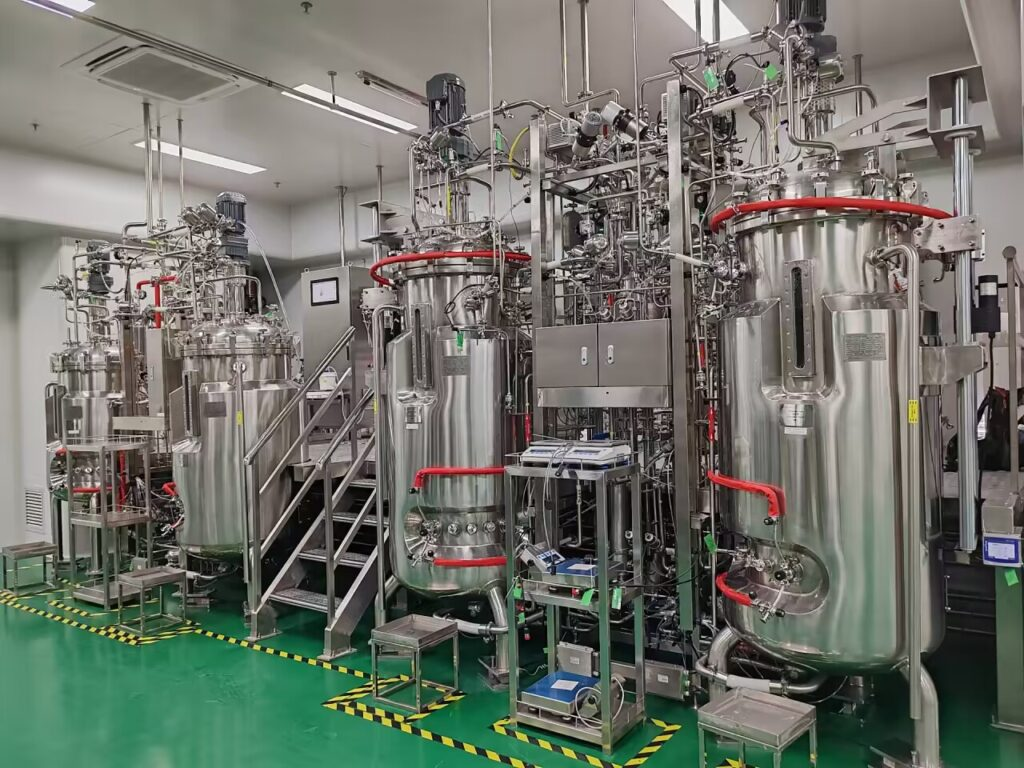

## **Modelo Matemático**

O sistema é descrito por duas equações diferenciais ordinárias acopladas para a concentração de reagente $C_A(t)$ e a temperatura do reator $T(t)$:

$$
\frac{dC_A}{dt} = \frac{F}{V}(C_{Ai} - C_A) - k_0 \exp\left(-\frac{E}{RT}\right) C_A
\tag{1}
$$

$$
\frac{dT}{dt} =
\frac{F}{V}(T_i - T)
+ \frac{-\Delta H}{\rho C_p} \, k_0 \exp\left(-\frac{E}{RT}\right) C_A
- \frac{UA}{\rho C_p V}(T - T_c)
\tag{2}
$$

---

### Variáveis de estado

- $C_A(t)$: concentração do reagente A $\left[\mathrm{mol/L}\right]$
- $T(t)$: temperatura do reator $\left[\mathrm{K}\right]$

---

### Variável manipulada

- $T_c(t)$: temperatura do fluido de resfriamento $\left[\mathrm{K}\right]$

---

### Condições iniciais

$$
C_A(0) = 0.5 \mathrm{mol/L}, \quad T(0) = 350 \mathrm{K}
$$

##**🔹 Passo 1 – Importar bibliotecas**

In [ ]:
...
...

##**🔹 Passo 2 – Inserir Dados do Problema**

In [ ]:
F = ...           # L/min
V = ...          # L
CA0 = ...        # mol/L
T0 = ...         # K

k0 = ...       # 1/min
E_R = ...        # K

dH = ...       # J/mol (exotérmica, mas usar valor positivo!)
rho = ...      # g/L
Cp = ...      # J/g.K

U = ...         # J/(min.m^2.K)
A = ...           # m^2

##**🔹 Passo 3 – Definir Sistema de Equações Diferenciais**

In [ ]:
def cstr_model(y, Tc):
    CA = y[0]
    T = y[1]

    # Constante de reação (Arrhenius)
    k = ...

    # Balanço de massa
    dCA_dt = ...

    # Balanço de energia
    dT_dt = ...

    f = np.array([dCA_dt, dT_dt])
    return f

##**🔹 Passo 4 – Inserir Condições de Simulação**

In [ ]:
# Condições iniciais
CA_init = ...      # mol/L
T_init =  ...     # K

t0 =           # Instante inicial
y0 = np.array([..., ...])

tf = ...            # Tempo final (min)

h = ...             # Passo de integração
n = int(...)        # Número de passos

##**🔹 Passo 5 – Definir Runge-Kutta 4a Ordem (RK4)**

In [ ]:
def metodo_Runge_Kutta(t0, y0, Tc, n, h):
    # t0 = valor inicial para t
    # y0 = valor inicial para y
    # n = número de passos
    # h = tamanho do passo

    # Criar os vetores de saída para t e y
    t = np.zeros(n)
    y = np.zeros((n,len(y0)))

    # Inicializar t e y com os valores iniciais
    t[0] = t0
    y[0,:] = y0

    # Loop principal para realizar os cálculos
    for i in range(0, n-1):

        # Avaliar as funções de Runge-Kutta
        k1 = cstr_model(y[i,:], Tc)
        k2 = cstr_model(y[i,:] + h*k1/2, Tc)
        k3 = cstr_model(y[i,:] + h*k2/2, Tc)
        k4 = cstr_model(y[i,:] + h*k3, Tc)

        # Atualizar y[i+1] pela média ponderada
        y[i+1,:] = y[i,:] + (h/6) *(k1 + 2*k2 + 2*k3 + k4)

        t[i+1] = t[i] + h   # Incrementa o valor de t

    # Retorna os vetores de saída com os valores de t e y calculados
    return t, y

##**🔹 Passo 6 – Resolver Caso 1: Diminuição do Resfriamento**

In [ ]:
Tc1 = ...  # mais resfriamento

t, sol1 = ...

##**🔹 Passo 7 – Plotar Concentração**

In [ ]:
plt.figure()

plt.plot(..., ..., label='CA (Tc baixo)')

plt.xlabel('Tempo (min)')
plt.ylabel('Concentração (mol/L)')
plt.legend()
plt.grid()

plt.show()

##**🔹 Passo 8 – Plotar Temperatura**

In [ ]:
plt.figure()

plt.plot(..., ..., label='T (Tc baixo)')

plt.xlabel('Tempo (min)')
plt.ylabel('Temperatura (K)')
plt.legend()
plt.grid()

plt.show()

##**🔹 Passo 9 – Resolver Caso 2: Aumento do Resfriamento**

In [ ]:
Tc2 = ...  # menos resfriamento

t, sol2 = ...

##**🔹 Passo 10 – Plotar Concentração**

In [ ]:
plt.figure()

plt.plot(..., ..., '-r', label='CA (Tc alto)')

plt.xlabel('Tempo (min)')
plt.ylabel('Concentração (mol/L)')
plt.legend()
plt.grid()

plt.show()

##**🔹 Passo 11 – Plotar Temperatura**

In [ ]:
plt.figure()

plt.plot(..., ..., '-r', label='T (Tc alto)')

plt.xlabel('Tempo (min)')
plt.ylabel('Temperatura (K)')
plt.legend()
plt.grid()

plt.show()

##**🔹 Passo 12 – Plotar Plano de Fases**

In [ ]:
plt.figure()

plt.plot(..., ..., label='Tc baixo')
plt.plot(..., ..., '-r', label='Tc alto')

plt.xlabel('$C_A (mol/L)$')
plt.ylabel('T (K)')
plt.legend()
plt.grid()

plt.show()

##**🔹 Passo 13 – (Opcional) Usar Subplots**

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(t, sol1[:,1], label='Tc baixo')
plt.plot(t, sol2[:,1], '-r', label='Tc alto')
plt.xlabel('tempo (min)')
plt.ylabel('$C_A (mol/L)$')
plt.legend()
plt.grid()

plt.subplot(1,3,2)
plt.plot(t, sol1[:,1], label='Tc baixo')
plt.plot(t, sol2[:,1], '-r', label='Tc alto')
plt.xlabel('tempo (min)')
plt.ylabel('T (K)')

plt.subplot(1,3,3)
plt.plot(sol1[:,0], sol1[:,1], label='Tc baixo')
plt.plot(sol2[:,0], sol2[:,1], '-r', label='Tc alto')

plt.xlabel('$C_A (mol/L)$')
plt.ylabel('T (K)')
plt.legend()
plt.grid()

plt.show()